In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [7]:
df = pd.read_csv('/kaggle/input/vesuvius-challenge-ink-detection/sample_submission.csv')
df.head()

,Id,Predicted
0,a,1 1 5 1
1,b,10 20


In [12]:
df.infer_objects()

,Id,Predicted
0,a,1 1 5 1
1,b,10 20


In [13]:
df.dtypes

Id           object
Predicted    object
dtype: object

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2 non-null      object
 1   Predicted  2 non-null      object
dtypes: object(2)
memory usage: 160.0+ bytes


In [16]:
df.describe().T

,count,unique,top,freq
Id,2,2,a,1
Predicted,2,2,1 1 5 1,1


In [20]:
df.isnull().sum()/len(df)*100

Id           0.0
Predicted    0.0
dtype: float64

In [21]:
df.shape

(2, 2)

<Axes: >

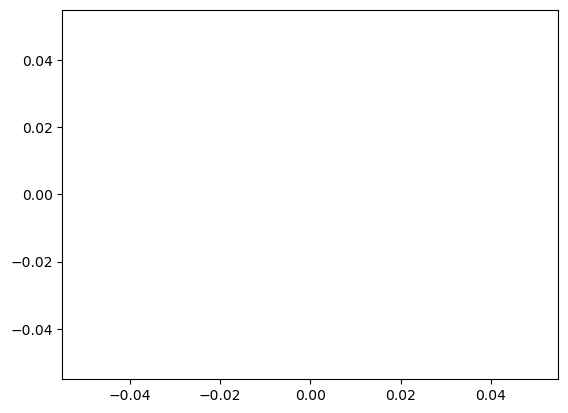

In [24]:
sns.scatterplot(df)

In [34]:
df['Predicted']=df['Predicted'].map({'Good':2,'Standard':1,'Poor':0})

/tmp/ipykernel_32/3130417409.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True,cmap='afmhot_r')
/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


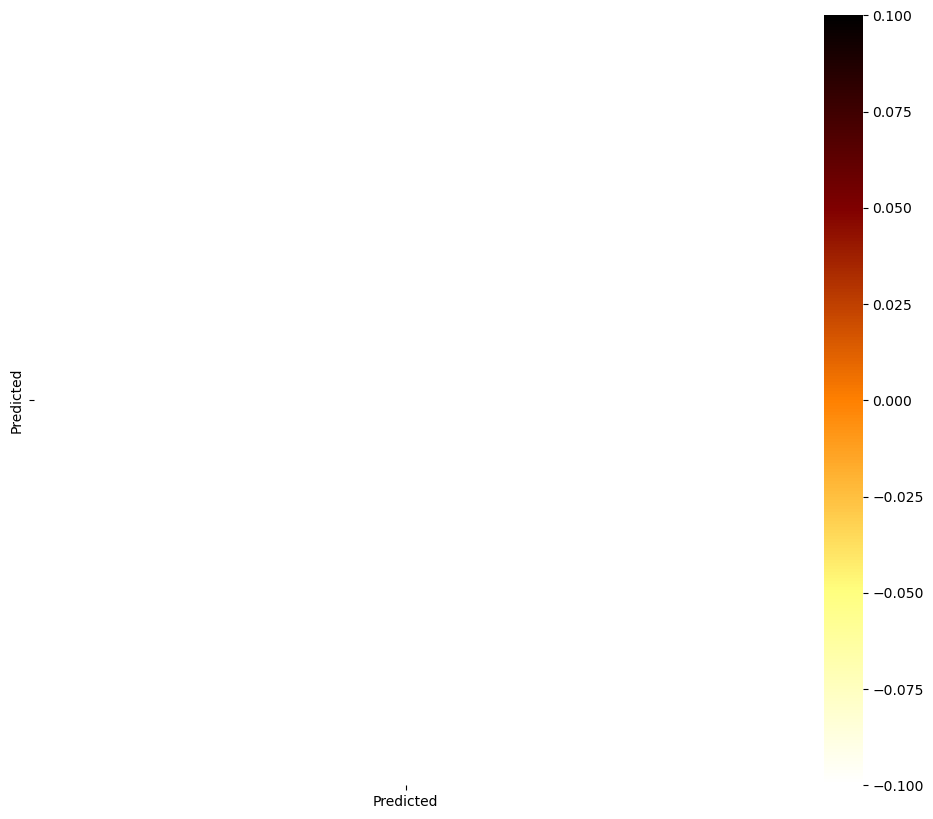

In [35]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='afmhot_r')
plt.show()

In [37]:
cat_cols = df.select_dtypes(include='object')

In [38]:
for i in cat_cols:
    print(i)
    print(df[i].value_counts())
    print('_'*50)

Id
a    1
b    1
Name: Id, dtype: int64
__________________________________________________


In [39]:
num_cols = df.select_dtypes(include='number')

In [40]:
for i in num_cols:
    print(i)
    print(df[i].value_counts())
    print('_'*50)

Predicted
Series([], Name: Predicted, dtype: int64)
__________________________________________________


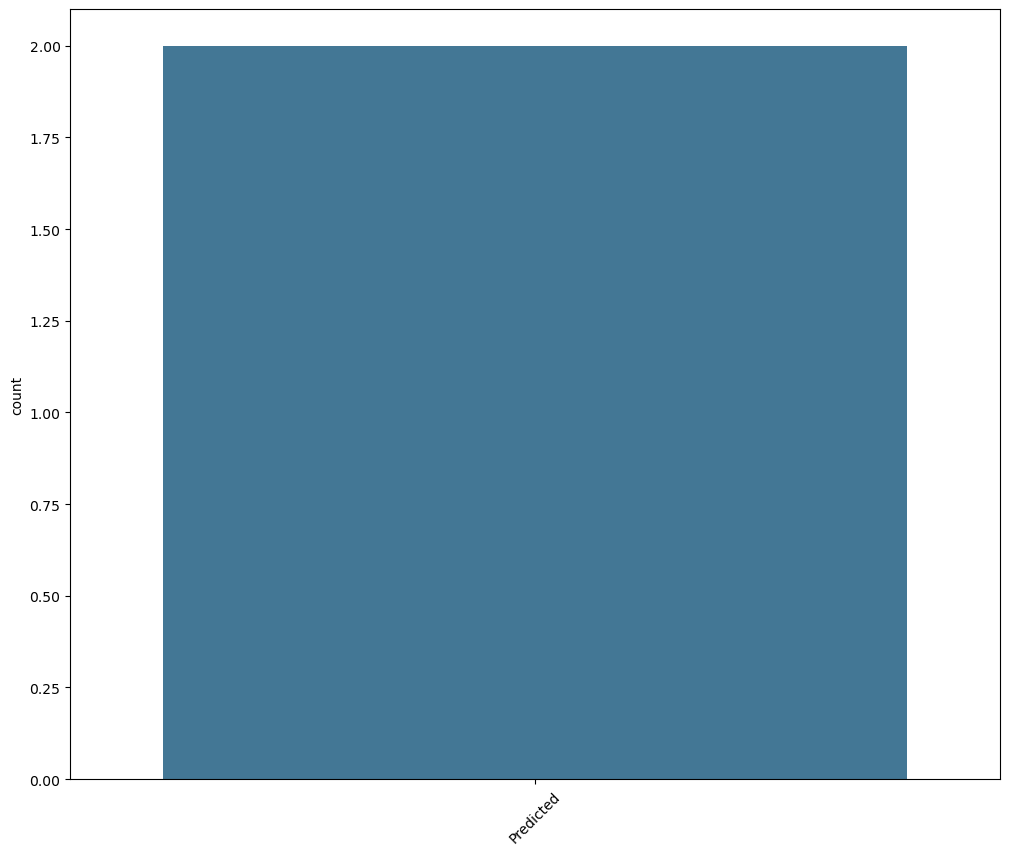

In [41]:
plt.figure(figsize=(12,10))
sns.countplot(df,palette='mako');
plt.xticks(rotation=45);

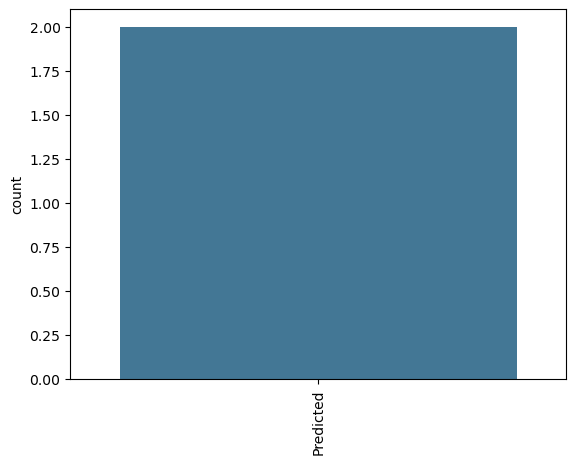

In [42]:
sns.countplot(df,palette='mako');
plt.xticks(rotation=90);

(array([0]), [Text(0, 0, '0')])

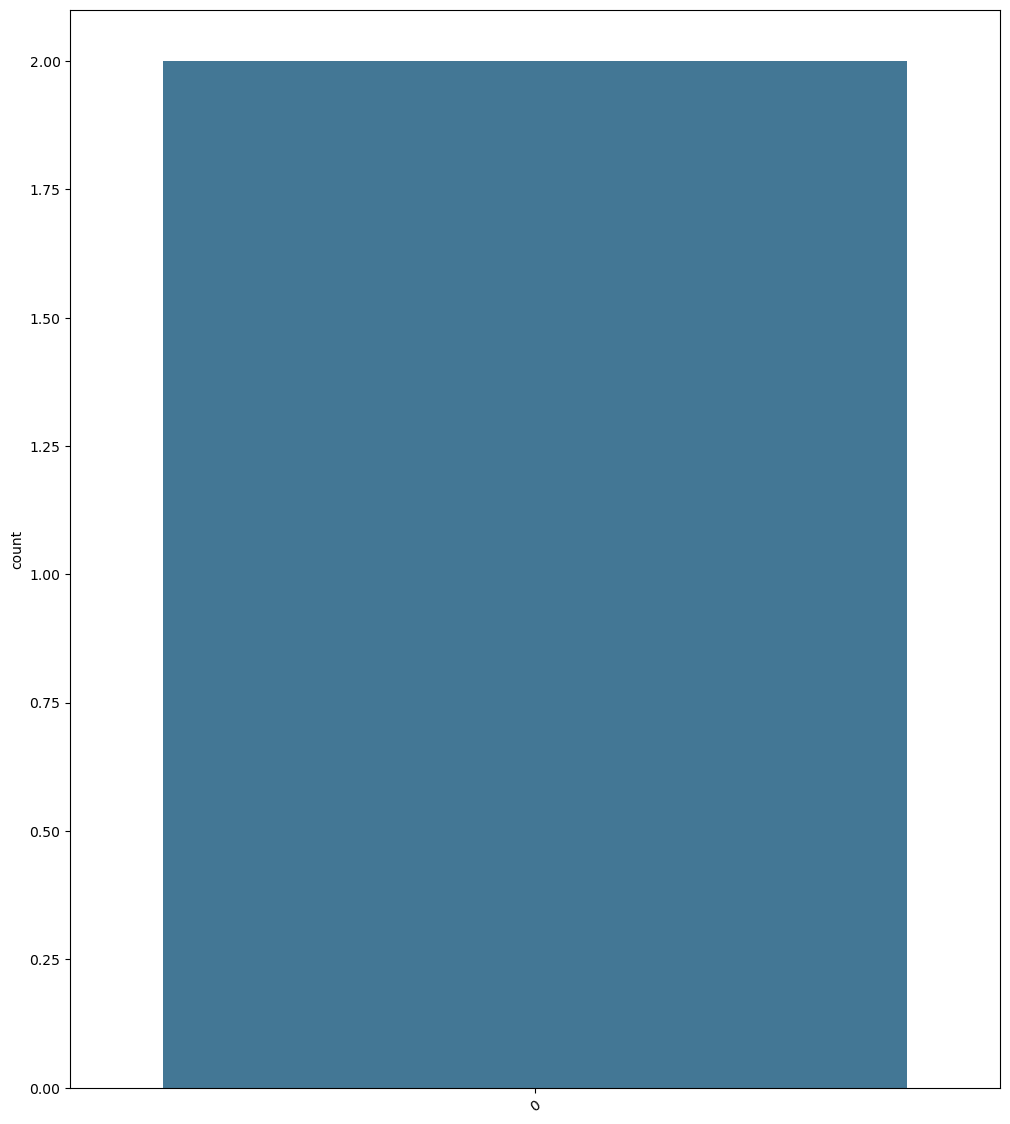

In [43]:
plt.figure(figsize=(12,14))
sns.countplot(df['Predicted'],palette='mako')
plt.xticks(rotation=35)

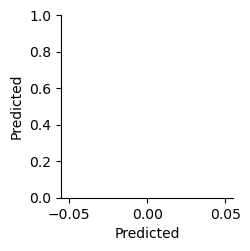

In [44]:
sns.pairplot(df)

In [45]:
df['Predicted'].value_counts()

Series([], Name: Predicted, dtype: int64)

In [46]:
df['Predicted'].unique()

array([nan])

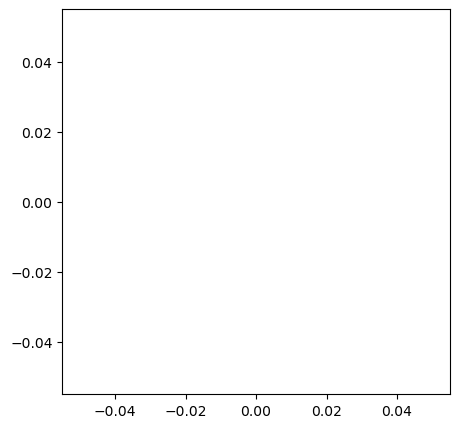

In [49]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=df,x=i,kde=True)
    print('\n')
    plt.show()

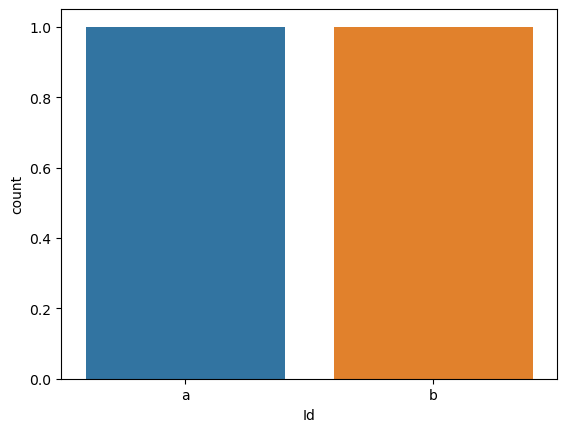

In [50]:
x=1
for i in cat_cols:
    sns.countplot(data=df,x=i)
    print('\n')
    plt.show()

<Axes: >

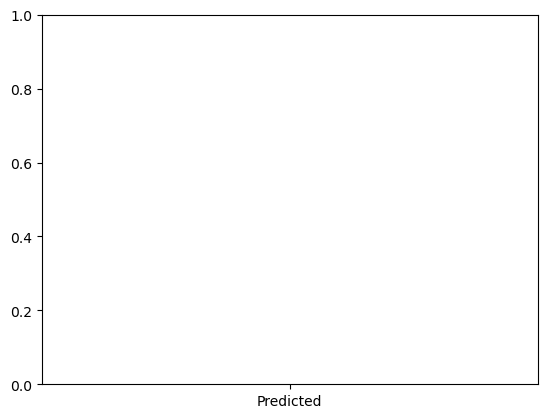

In [51]:
sns.boxplot(df)

<Axes: ylabel='Density'>

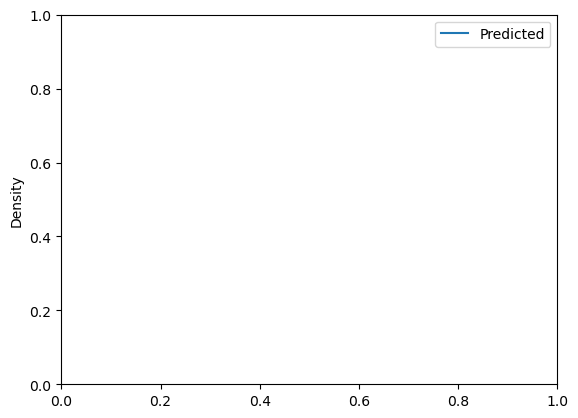

In [52]:
sns.kdeplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


<Axes: >

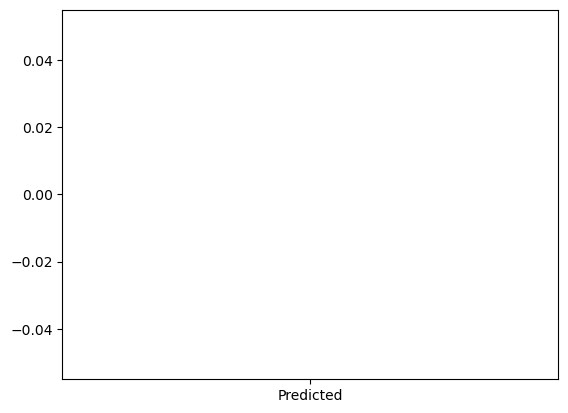

In [53]:
sns.barplot(df)

<Axes: >

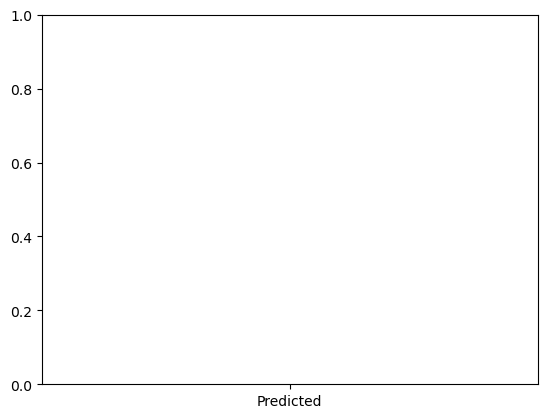

In [54]:
sns.violinplot(df)

<Axes: >

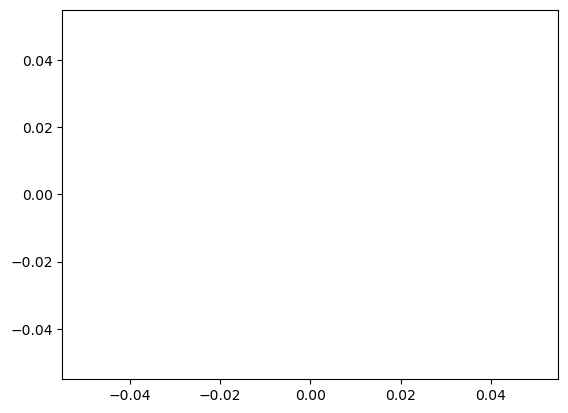

In [55]:
sns.scatterplot(df)

<Axes: >

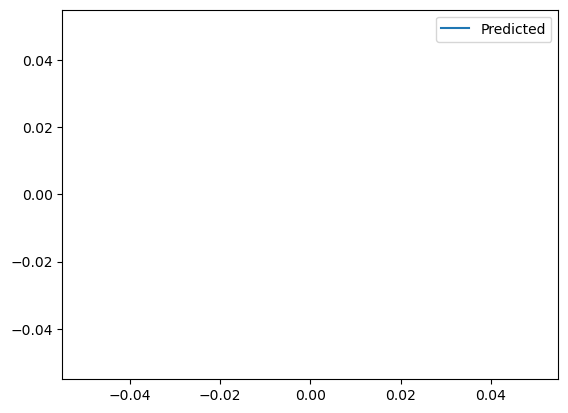

In [56]:
sns.lineplot(df)

In [58]:
df.skew()

/tmp/ipykernel_32/1665899112.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.skew()


Predicted   NaN
dtype: float64

In [59]:
df.kurt()

/tmp/ipykernel_32/1257127604.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.kurt()


Predicted   NaN
dtype: float64

/tmp/ipykernel_32/2582663562.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True,cmap='afmhot')


<Axes: >

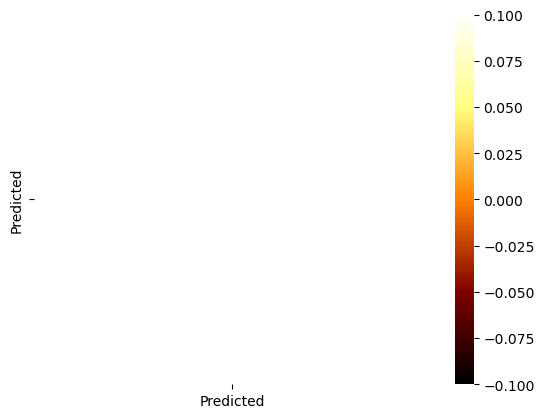

In [65]:
sns.heatmap(df.corr(),annot=True,cmap='afmhot')

In [77]:
df['Predicted'].value_counts().head(9).index[1:]

Float64Index([], dtype='float64')

In [79]:
# Rebuild type of Predicted
for i in df['Predicted'].value_counts().head(9).index[1:]:
    df[i]=df['Predicted'].str.contains(i)

In [81]:
df.head()

,Id,Predicted
0,a,NaN
1,b,NaN
